In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [4]:
df = pd.read_csv("/content/Metro_Interstate_Traffic_Volume.csv")

df.head()


Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume'],
      dtype='object')

In [5]:
df.columns

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'weather_description', 'date_time', 'traffic_volume'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
holiday,48143
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0


In [7]:
df.drop_duplicates(inplace=True)

print(df.shape)

(48187, 9)


In [8]:
df['date_time'] = pd.to_datetime(df['date_time'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48187 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   holiday              61 non-null     object        
 1   temp                 48187 non-null  float64       
 2   rain_1h              48187 non-null  float64       
 3   snow_1h              48187 non-null  float64       
 4   clouds_all           48187 non-null  int64         
 5   weather_main         48187 non-null  object        
 6   weather_description  48187 non-null  object        
 7   date_time            48187 non-null  datetime64[ns]
 8   traffic_volume       48187 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 3.7+ MB


In [10]:
df['hour'] = df['date_time'].dt.hour

df['day'] = df['date_time'].dt.day

df['month'] = df['date_time'].dt.month

df['weekday'] = df['date_time'].dt.weekday

In [11]:
df[['date_time','hour','day','month','weekday']].head()

,date_time,hour,day,month,weekday
0,2012-10-02 09:00:00,9,2,10,1
1,2012-10-02 10:00:00,10,2,10,1
2,2012-10-02 11:00:00,11,2,10,1
3,2012-10-02 12:00:00,12,2,10,1
4,2012-10-02 13:00:00,13,2,10,1


In [12]:
df['traffic_volume'].describe()

,traffic_volume
count,48187.000000
mean,3259.618134
std,1986.954465
min,0.000000
25%,1192.500000
50%,3379.000000
75%,4933.000000
max,7280.000000


In [13]:
def classify_traffic(x):
    if x < 1200:
        return "Low"
    elif x < 4900:
        return "Medium"
    else:
        return "High"

df['traffic_level'] = df['traffic_volume'].apply(classify_traffic)

In [14]:
df['traffic_level'].value_counts()

,count
traffic_level,
Medium,23676
High,12420
Low,12091


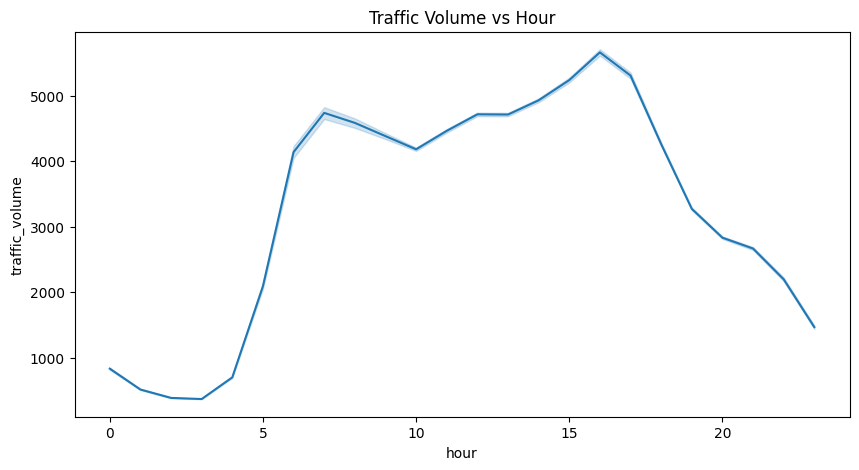

In [15]:
plt.figure(figsize=(10,5))
sns.lineplot(x='hour', y='traffic_volume', data=df)
plt.title("Traffic Volume vs Hour")
plt.show()

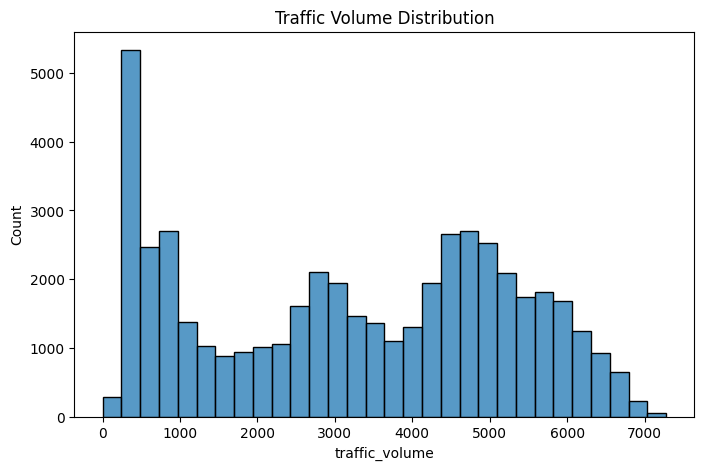

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['traffic_volume'], bins=30)
plt.title("Traffic Volume Distribution")
plt.show()

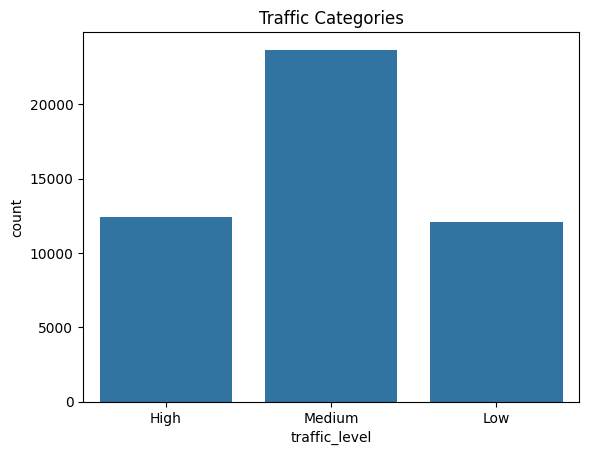

In [17]:
sns.countplot(x='traffic_level', data=df)
plt.title("Traffic Categories")
plt.show()

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['holiday'] = le.fit_transform(df['holiday'])

df['weather_main'] = le.fit_transform(df['weather_main'])

df['traffic_level'] = le.fit_transform(df['traffic_level'])

In [19]:
X = df[
[
'temp',
'rain_1h',
'snow_1h',
'clouds_all',
'hour',
'weekday',
'month',
'weather_main'
]
]

y = df['traffic_level']

In [20]:
print(X.shape)
print(y.shape)

(48187, 8)
(48187,)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [23]:
y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9279933596181781


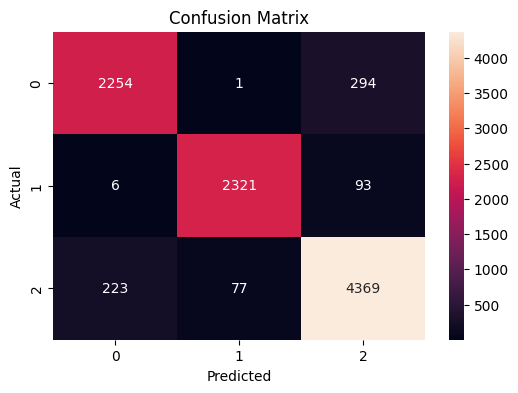

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.88      0.90      2549
           1       0.97      0.96      0.96      2420
           2       0.92      0.94      0.93      4669

    accuracy                           0.93      9638
   macro avg       0.93      0.93      0.93      9638
weighted avg       0.93      0.93      0.93      9638



In [27]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

        Feature  Importance
4          hour    0.661110
0          temp    0.133164
5       weekday    0.109312
6         month    0.037740
3    clouds_all    0.030795
7  weather_main    0.018239
1       rain_1h    0.009102
2       snow_1h    0.000537


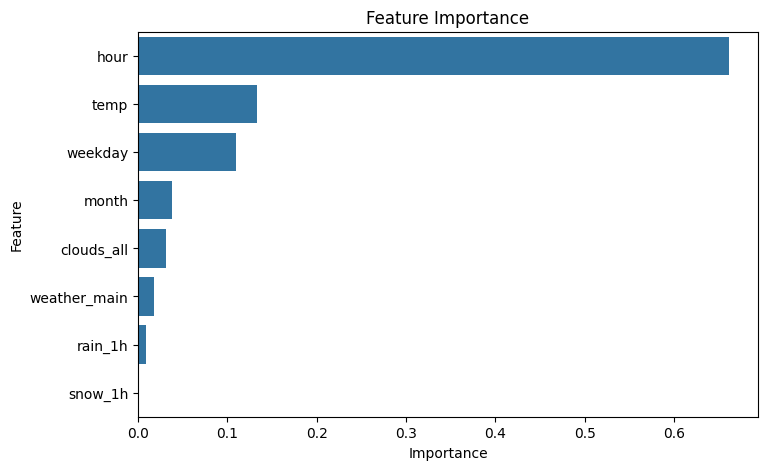

In [28]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.title("Feature Importance")
plt.show()

In [29]:
import joblib

joblib.dump(model, 'traffic_model.pkl')

['traffic_model.pkl']

In [30]:
from google.colab import files

files.download('traffic_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>